In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime

import matplotlib.pyplot as plt

In [3]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

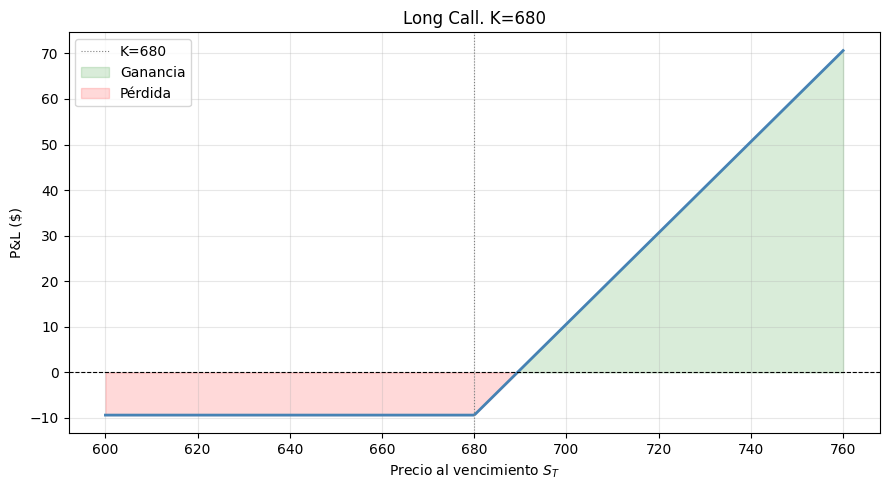

In [4]:
legs_call = [
    {'tipo': 'call', 'K': 680, 'prima': 9.37, 'posicion': +1}
]

pnl = payoff_estrategia(S_range, legs_call)
graficar_estrategia(S_range, pnl, 'Long Call. K=680',
                    K_lines=[(680, 'K=680')])

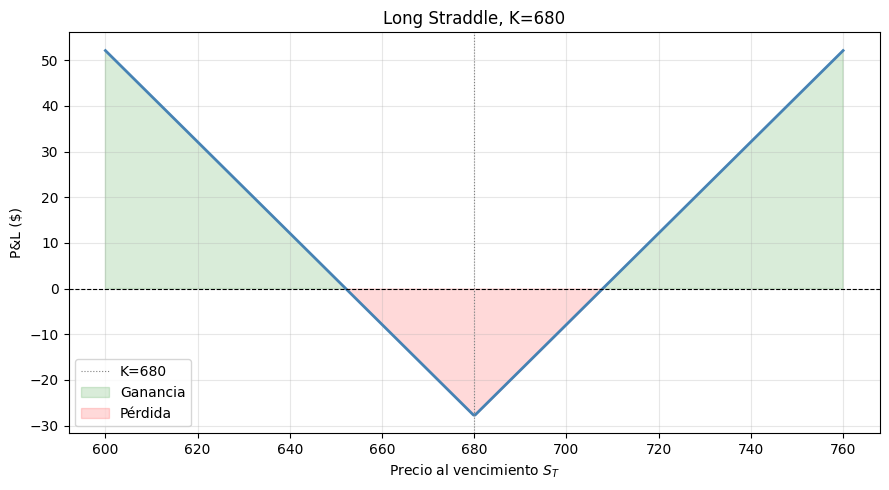

In [8]:
graficar_estrategia(S_range, pnl, f'Long Straddle, K={K}',
                    K_lines=[(K, f'K={K}')])

## LONG STRADDLE 

In [10]:
def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8,5))
    plt.plot(S_range, pnl, label='P&L')
    plt.axhline(0)

    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, linestyle='--', label=label)

    # 👉 agregar S0
    if S0 is not None:
        plt.axvline(S0, linestyle=':', label=f'S0={S0}', color='black')

    plt.title(titulo)
    plt.legend()
    plt.show()

## LONG STRANGLE 

Costo total        : $16.00  (vs $27.87 del straddle)
Break-even sup.    : $716.00
Break-even inf.    : $644.00


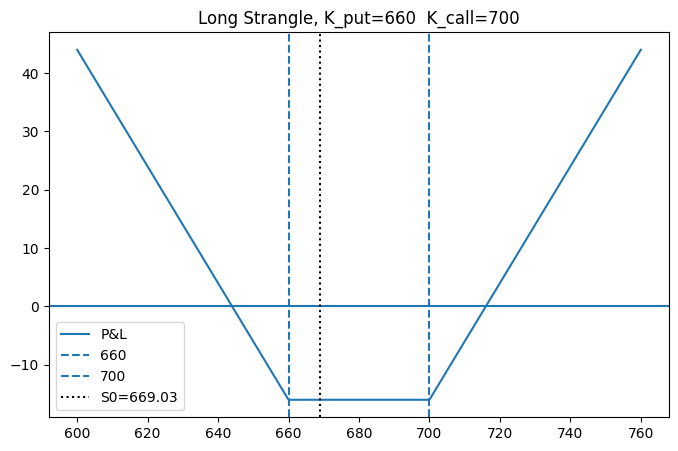

In [11]:
K_call, K_put = 700, 660
C_otm, P_otm  = 5.20, 10.80

legs_strangle = [
    {'tipo': 'call', 'K': K_call, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': K_put,  'prima': P_otm,  'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_strangle)

print(f"Costo total        : ${C_otm+P_otm:.2f}  (vs ${C+P:.2f} del straddle)")
print(f"Break-even sup.    : ${K_call+C_otm+P_otm:.2f}")
print(f"Break-even inf.    : ${K_put-C_otm-P_otm:.2f}")

graficar_estrategia(S_range, pnl, f'Long Strangle, K_put={K_put}  K_call={K_call}',
                    S0=S0, K_lines=[(K_put, f'{K_put}'), (K_call, f'{K_call}')])

Prima neta pagada  : $9.30
Ganancia máxima    : $20.70  (si ST ≥700)
Pérdida máxima     : $-9.30  (si ST ≤670)
Break-even         : $679.30


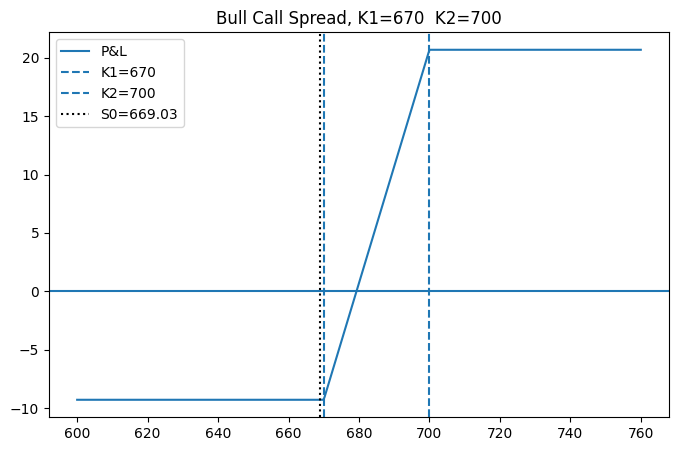

In [13]:
K1, K2 = 670, 700
C1, C2 = 14.50, 5.20

legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},
]
pnl = payoff_estrategia(S_range, legs_bull)
prima_neta = C1 - C2

print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K2-K1)-prima_neta:.2f}  (si ST ≥{K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≤{K1})")
print(f"Break-even         : ${K1+prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Bull Call Spread, K1={K1}  K2={K2}',
                    S0=S0, K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')])

Prima neta pagada  : $10.30
Ganancia máxima    : $19.70  (si ST ≤650)
Pérdida máxima     : $-10.30  (si ST ≥680)
Break-even         : $669.70


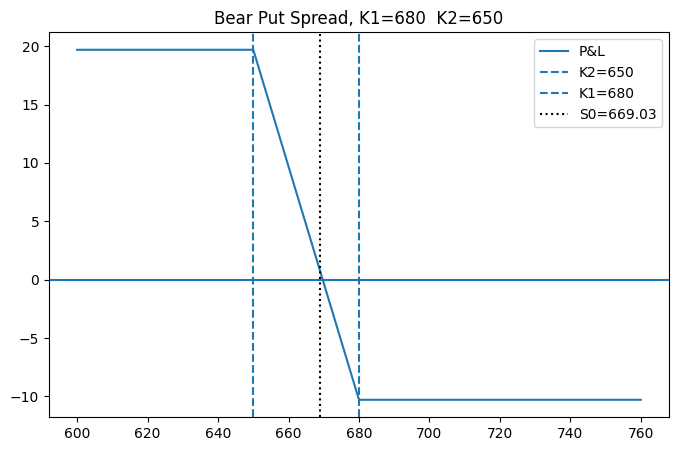

In [14]:
K1, K2 = 680, 650
P1, P2 = 18.50, 8.20

legs_bear = [
    {'tipo': 'put', 'K': K1, 'prima': P1, 'posicion': +1},
    {'tipo': 'put', 'K': K2, 'prima': P2, 'posicion': -1},
]
pnl = payoff_estrategia(S_range, legs_bear)
prima_neta = P1 - P2

print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K1-K2)-prima_neta:.2f}  (si ST ≤{K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≥{K1})")
print(f"Break-even         : ${K1-prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Bear Put Spread, K1={K1}  K2={K2}',
                    S0=S0, K_lines=[(K2, f'K2={K2}'), (K1, f'K1={K1}')])

CONCLUSIONES :
El long straddle

Porque S0 está casi en K=680, que es justo donde el straddle pierde más (el “valle” del gráfico).
Quiero decir que Estás apostando a que el mercado se va a mover fuerte, pero ahora mismo estás en el peor punto → necesitas movimiento sí o sí.


Straddle vs Strangle (costo y movimiento)
Straddle cuesta: C + P = 9.37 + 18.50 = 27.87
Strangle es más barato (porque strikes están más lejos)
 El strangle es más barato, pero:

Necesitas que SPY se mueva más lejos para ganar
Break-evens están más abiertos

 En corto:
Strangle = más barato pero más exigentec

Comprar straddle con IV alta (antes de evento) Mala idea en general Porque: Ya pagaste primas caras (IV alta) después del evento → IV cae (vol crush)
Aunque el precio se mueva, puedes igual perder
Es decir : necesitas un movimiento MUCHO más grande para compensar

Por qué usar bull call spread en vez de call simple? Dos razones claras: Más barato (vendes una call)Menos riesgo / menos theta decay
 Aceptas ganancia limitada a cambio de mejor costo y menor desgaste.

 Si SPY pasa K2 antes del vencimiento Depende, pero muchas veces sí conviene cerro
1. Tiempo restante (queda mucho → puede caer)
2. Theta (ya no ganas más arriba de K2)
3. Ganancia ya capturada

Impacto de IV: straddle vs bull spread
 Straddle es MUCHO más sensible
Straddle: vega alta → gana si sube IV
Bull spread: vega baja → efecto más chico
Porque en el spread compras y vendes opciones  enronces se compensan
Griegas: call vs bull spread
La que más cambia: VEGA (y también gamma)

Call simple:
más delta
más gamma
más vega
Bull spread:
todo más “suavizado”

En corto:
**Spread** = versión más controlada y menos agresiva
